# Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!pip install insightface


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 87.8 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071345 sha256=2a29389c481e935e9c5a90b5418be55a4b938a23e690bd416dd2d4088ca25985
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [5]:
!pip install onnxruntime-gpu # GPU version
!pip install onnxruntime     # CPU version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 32.5 MB/s eta 0:00:00


In [6]:
import onnxruntime
print("ONNX Runtime version:", onnxruntime.__version__)


ONNX Runtime version: 1.23.2


# Extract Models

In [34]:
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image
import cv2
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
from numpy.linalg import norm
from tqdm import tqdm


In [10]:

def load_insightface_model(model_zip_path):
    """
    Simple function to unzip and get path for any InsightFace model
    """

    # Base extraction directory
    base_extract_path = '/content/insightface_models/'
    os.makedirs(base_extract_path, exist_ok=True)

    # Get model name from zip file
    model_name = os.path.basename(model_zip_path).replace('.zip', '')
    model_extract_path = os.path.join(base_extract_path, model_name)

    # Extract if not already extracted
    if not os.path.exists(model_extract_path):
        print(f"Extracting {model_name}...")
        with zipfile.ZipFile(model_zip_path, 'r') as zip_ref:
            zip_ref.extractall(base_extract_path)
        print(f"Model extracted to: {model_extract_path}")
    else:
        print(f"Model already exists at: {model_extract_path}")

    return model_extract_path


In [11]:
# Usage for different models
buffalo_l_path = load_insightface_model('/content/drive/MyDrive/insightface_models/buffalo_l.zip')

print(f"Model ready at: {buffalo_l_path}")

Extracting buffalo_l...
Model extracted to: /content/insightface_models/buffalo_l
Model ready at: /content/insightface_models/buffalo_l


In [12]:
buffalo_sc_path = load_insightface_model('/content/drive/MyDrive/insightface_models/buffalo_sc.zip')

print(f"Model ready at: {buffalo_sc_path}")

Extracting buffalo_sc...
Model extracted to: /content/insightface_models/buffalo_sc
Model ready at: /content/insightface_models/buffalo_sc


In [13]:
app_l = FaceAnalysis(name='buffalo_l',
                     root=buffalo_l_path,
                     providers=['CPUExecutionProvider']
                     )
app_l.prepare(ctx_id=0, det_size=(640, 640))


download_path: /content/insightface_models/buffalo_l/models/buffalo_l


100%|██████████| 281857/281857 [00:07<00:00, 37125.16KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/insightface_models/buffalo_l/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/insightface_models/buffalo_l/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/insightface_models/buffalo_l/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/insightface_models/buffalo_l/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/insightface_models/buffalo_l/models/buffalo_l/w60

In [14]:
app_sc = FaceAnalysis(name='buffalo_sc',
                     root=buffalo_sc_path,
                     providers=['CPUExecutionProvider']
                     )
app_sc.prepare(ctx_id=0, det_size=(640, 640))


download_path: /content/insightface_models/buffalo_sc/models/buffalo_sc


100%|██████████| 14619/14619 [00:00<00:00, 24078.10KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/insightface_models/buffalo_sc/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/insightface_models/buffalo_sc/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


**`prepare` Method Parameters Explained**

1. `ctx_id` (Context ID)

    Purpose: Specifies which GPU/device to use for inference
    Values:

-   `ctx_id=-1` or `ctx_id='cpu'`: Use CPU only

-    `ctx_id=0`: Use GPU 0 (first GPU)

2. `det_size` (Detection Size)

    Purpose: Input image size for face detection
3. `det_thresh` (Detection Threshold)

    Purpose: Confidence threshold for face detection
4. `rec_thresh` (Recognition Threshold)

    Purpose: Threshold for face recognition matching
5. `input_size`

    Purpose: Size for face recognition embedding

In [52]:
# Read and process image
image_path = '/content/drive/MyDrive/insightface_models/Faces/34 - test-image-2.jpg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

result_l = app_l.get(img_rgb)
result_sc = app_sc.get(img_rgb)

In [16]:
print(f"Number of faces detected by baffalo_l: {len(result_l)}")
print(f"Number of faces detected by baffalo_sc: {len(result_sc)}")

Number of faces detected by baffalo_l: 21
Number of faces detected by baffalo_sc: 21


In [17]:
print(f"Key of Baffalo_L: {result_l[0].keys()}")
print(f"Key of Baffalo_SC: {result_sc[0].keys()}")

Key of Baffalo_L: dict_keys(['bbox', 'kps', 'det_score', 'landmark_3d_68', 'pose', 'landmark_2d_106', 'gender', 'age', 'embedding'])
Key of Baffalo_SC: dict_keys(['bbox', 'kps', 'det_score', 'embedding'])


-    `bbox` - Bounding box coordinates

-    `kps` - Key points (basic landmarks, usually 5 points)

 -   `det_score` - Detection confidence score

  -  `embedding` - Face recognition vector
    
   - `landmark_3d_68` - 3D facial landmarks (68 points)

-    `pose` - Head pose estimation (pitch, yaw, roll)

-    `landmark_2d_106` - Detailed 2D facial landmarks (106 points)

-    `gender` - Gender classification

-    `age` - Age estimation

In [18]:
print(result_l[0]['bbox'] ,'\n') # two point that represent the corners of the box
print(result_l[0]['kps'] ,'\n') # key points
print(result_l[0]['det_score'] ) # confidence score

[1021.09735  182.74878 1091.9272   277.86517] 

[[1041.8057   216.62466]
 [1075.753    216.2792 ]
 [1060.4359   238.03854]
 [1041.2188   247.48323]
 [1076.7723   247.31699]] 

0.9268838


In [19]:
def display_faces(image_rgb, result):
    """
    Display detected faces with boxes, keypoints, and age/gender if available.

    image_rgb : RGB image from cv2.cvtColor
    result    : Output list from InsightFace model app.get()
    """

    img_out = image_rgb.copy()
    gender_encoder = ['Female', 'Male']

    for face in result:
        x1, y1, x2, y2 = face.bbox.astype(int)

        # Draw bounding box
        cv2.rectangle(img_out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw keypoints
        kps = face.kps.astype(int)
        for k1, k2 in kps:
            cv2.circle(img_out, (k1, k2), 2, (0, 0, 255), -1)

        # Detection score
        score_text = f"Score: {face.det_score:.2f}"
        cv2.putText(img_out, score_text, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 1)

        # -------------------------
        # Check if model has age/gender
        # buffalo_l  → has 'age' and 'gender'
        # buffalo_sc → does NOT have them
        # -------------------------
        if 'age' in face and 'gender' in face:
            gender_text = gender_encoder[face['gender']]
            age_text = f"{gender_text}, {face['age']} yrs"
            cv2.putText(img_out, age_text, (x1, y2 + 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 1)

    # Show correctly in RGB
    plt.figure(figsize=(8, 8))
    plt.imshow(img_out)
    plt.axis("off")
    plt.show()


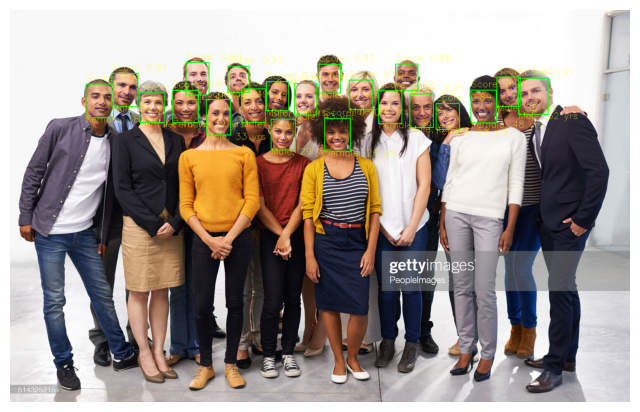

In [20]:
# Simplest usage
display_faces(img_rgb, result_l)


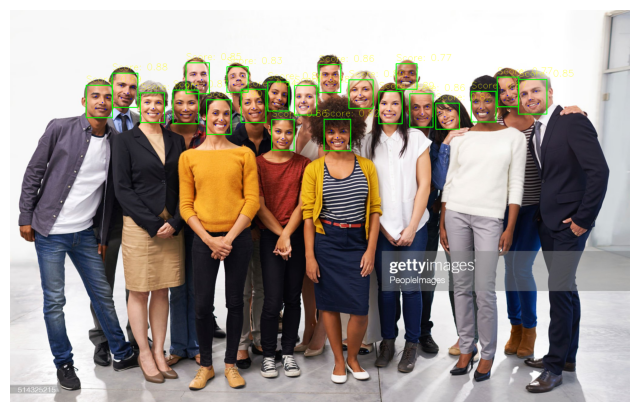

In [21]:
display_faces(img_rgb, result_sc)

# Face Recognition (Embeddings + Matching)

In [1]:
def compare_faces(embedding1, embedding2, threshold=0.6):
    """Compare two face embeddings using cosine similarity"""
    from numpy.linalg import norm
    cosine_similarity = np.dot(embedding1, embedding2) / (norm(embedding1) * norm(embedding2))
    return cosine_similarity, cosine_similarity > threshold

In [23]:
# Read and process image
Cristiano_image_path = '/content/drive/MyDrive/insightface_models/Faces/Cristiano_Ronaldo_1.jpg'
Cristiano_img_1 = cv2.imread(Cristiano_image_path)
Cristiano_img_1 = cv2.cvtColor(Cristiano_img_1, cv2.COLOR_BGR2RGB)

Cristiano_1 = app_l.get(Cristiano_img_1)

Cristiano_image_path = '/content/drive/MyDrive/insightface_models/Faces/Cristiano_Ronaldo_2.jpg'
Cristiano_img_2 = cv2.imread(Cristiano_image_path)
Cristiano_img_2 = cv2.cvtColor(Cristiano_img_2, cv2.COLOR_BGR2RGB)

Cristiano_2 = app_l.get(Cristiano_img_2)


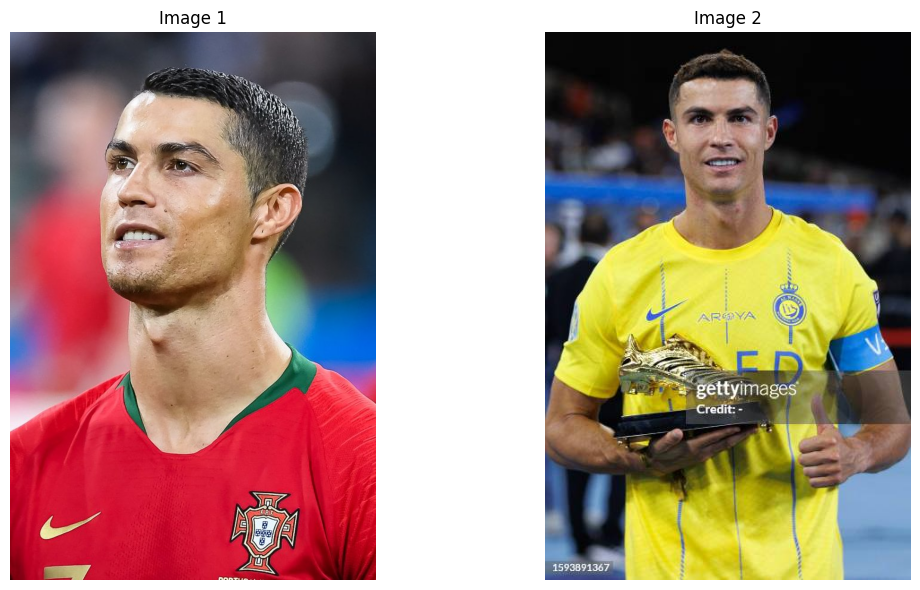

In [25]:
# Create subplots - 1 row, 2 columns
plt.figure(figsize=(12, 6))

# First image
plt.subplot(1, 2, 1)  # (rows, columns, position)
plt.imshow(Cristiano_img_1)
plt.title('Image 1')
plt.axis('off')

# Second image
plt.subplot(1, 2, 2)
plt.imshow(Cristiano_img_2)
plt.title('Image 2')
plt.axis('off')

plt.tight_layout()
plt.show()

In [51]:
len(Cristiano_1[0]['embedding']) , len(Cristiano_2[0]['embedding'])

(512, 512)

**A 512-dimensional vector representing the face detection**

In [30]:
# Example usage
embedding1 = Cristiano_1[0]['embedding']
embedding2 = Cristiano_2[0]['embedding']

if embedding1 is not None and embedding2 is not None:
    similarity, is_match = compare_faces(embedding1, embedding2)
    print(f"Similarity: {similarity:.4f}, Match: {is_match}")

Similarity: 0.6480, Match: True


  This is the cosine similarity between two face embeddings Range: -1.0 to 1.0

   - 1.0 = Exactly the same person (perfect match)

   - 0.0 = Completely different (no relationship)

   - -1.0 = Perfect opposites (theoretical minimum)

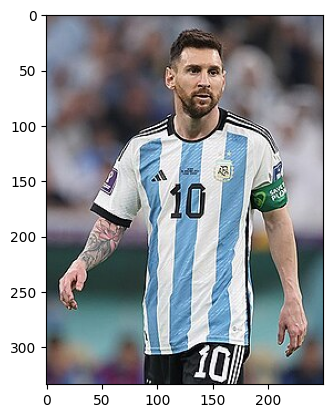

In [31]:
Mess_image_path = '/content/drive/MyDrive/insightface_models/Faces/Lionel-Mess.jpg'
Mess_img = cv2.imread(Mess_image_path)
Mess_img = cv2.cvtColor(Mess_img, cv2.COLOR_BGR2RGB)


Mess = app_l.get(Mess_img)

plt.imshow(Mess_img)


In [33]:
embedding3 = Mess[0]['embedding']
similarity, is_match = compare_faces(embedding1, embedding3)
print(f"Similarity: {similarity:.4f}, Match: {is_match}")

Similarity: -0.0958, Match: False


# Processing a Dataset

In [41]:
def create_face_database(dataset_folder, model):
    """Create a database of face embeddings from a dataset folder

    Args:
        dataset_folder (str): Path to the dataset folder
        model: Pre-initialized InsightFace model instance

    Returns:
        dict: Face database with person names as keys and average embeddings as values
    """
    face_database = {}

    for person_name in os.listdir(dataset_folder):
        person_path = os.path.join(dataset_folder, person_name)

        if os.path.isdir(person_path):
            embeddings = []
            for img_file in tqdm(os.listdir(person_path), desc=f"Processing {person_name}"):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(person_path, img_file)
                    img = cv2.imread(img_path)

                    # Check if image was loaded successfully
                    if img is None:
                        print(f"Warning: Could not load image {img_path}")
                        continue

                    faces = model.get(img)

                    if len(faces) > 0:
                        embeddings.append(faces[0].embedding)
                    else:
                        print(f"Warning: No faces detected in {img_path}")

            if embeddings:
                # Average embeddings for the person
                avg_embedding = np.mean(embeddings, axis=0)
                face_database[person_name] = avg_embedding
                print(f"Added {person_name} with {len(embeddings)} face samples")
            else:
                print(f"Warning: No valid face embeddings found for {person_name}")

    return face_database

In [37]:
def identify_face(embedding, face_database, threshold=0.6):
    """Identify a face against the database"""
    best_match = None
    best_similarity = 0

    for name, db_embedding in face_database.items():
        similarity, _ = compare_faces(embedding, db_embedding, threshold)
        if similarity > best_similarity:
            best_similarity = similarity
            best_match = name

    return best_match, best_similarity

In [42]:
dataset_path = "/content/drive/MyDrive/insightface_models/dataset_folder"
face_database = create_face_database(dataset_path, app_l)

Processing Cristiano_Ronaldo: 100%|██████████| 3/3 [00:04<00:00,  1.37s/it]


Added Cristiano_Ronaldo with 3 face samples


Processing Lionel_Mess: 100%|██████████| 3/3 [00:06<00:00,  2.09s/it]


Added Lionel_Mess with 3 face samples


Processing Mohamed_Salah: 100%|██████████| 3/3 [00:04<00:00,  1.65s/it]

Added Mohamed_Salah with 3 face samples


In [43]:
print(f"Database created with {len(face_database)} people")

Database created with 3 people


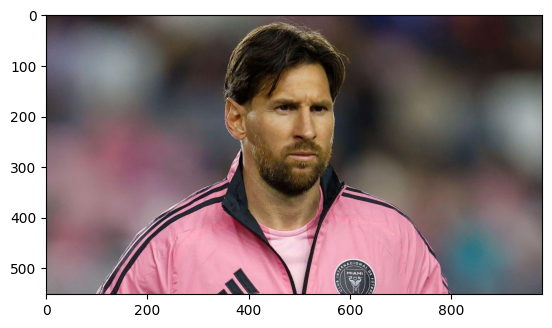

In [47]:
New_person_path = '/content/drive/MyDrive/insightface_models/Faces/Lionel_Mess_4.jpg'
person_img = cv2.imread(New_person_path)
person_img = cv2.cvtColor(person_img, cv2.COLOR_BGR2RGB)


person = app_l.get(Mess_img)
embedding =   person[0]['embedding']
plt.imshow(person_img)



In [48]:
best_match, best_similarity = identify_face(embedding, face_database)
print(f"Best Match: {best_match}, Similarity: {best_similarity}")

Best Match: Lionel_Mess, Similarity: 0.6919623017311096
